### Load SLM library

- if using simulation mode, choose `sim_mode=True`
- if using SLM, choose `sim_mode=False`

- if using SLM, check its status. Status LED should be *green* (not blink)
    - if blink, turn off SLM, restart computer, turn on SLM
    - still not work? Then re-install blink
        - Start menu ->  Type "blink" -> Close VS CODE -> uninstall
        - Start menu ->  Type "blink" -> Blink & SDK installer -> install
        - re-run this block   

In [1]:
from hardware import SLMManager,RemoteSLMManager
import torch

remote_mode = True
sim_mode = False

if sim_mode:
    # simulation mode
    slm_manager = SLMManager(sim_mode=True)
elif remote_mode:
    # remote SLM control
    slm_manager = RemoteSLMManager()
else: 
    # local SLM control
    slm_manager = SLMManager(sim_mode=False)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Connecting to local hardware service at 127.0.0.1:18861 ...
✅ Connected to local SLM


### Load/Overwrite BASE param and save json, Use Fresnel Lens to Test

- Most parameters are set within `config.py` as default values and are loaded here as `params`
- Finally, test this parameter on Fresnel phase.
- You can overwrite them here.


JSON file saved to: .\\config\\base_M5.json
Using device: cuda
F/47.31, 73.89999999999999 mm
Lens width: 1.562mm
Airy radius: 29.7um
Depth of focus: 2.31mm
Multi-depth planes are used at F=72.7 (-0.5DOF), 75.1 (0.5DOF) mm
Fresnel Lens: 850x850 px; 5x5 lenses
🚀 Data sent to local hardware
Sub-Image size  1.56 mm
Sub-Image pixel  53 x 53


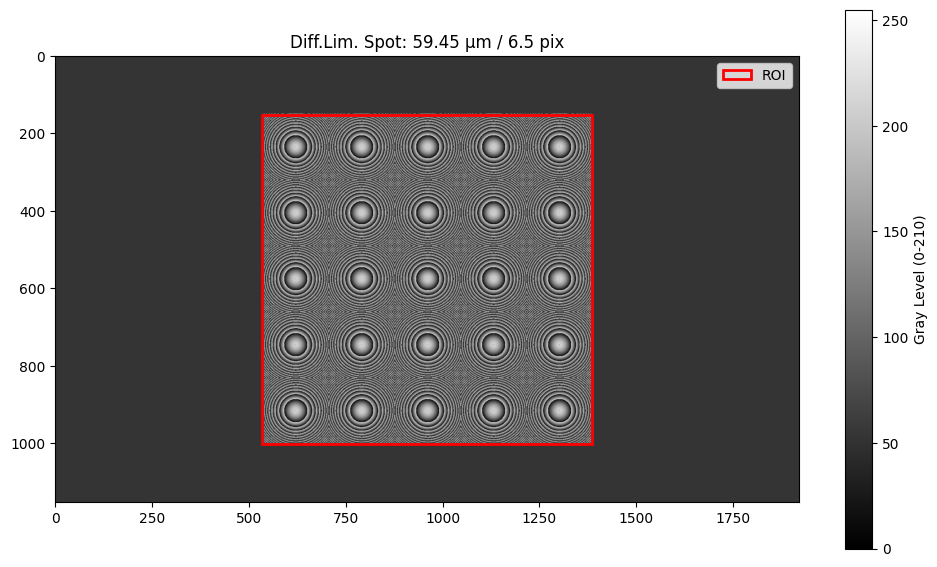

d:\Zihan\code\slm_project\visualization.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


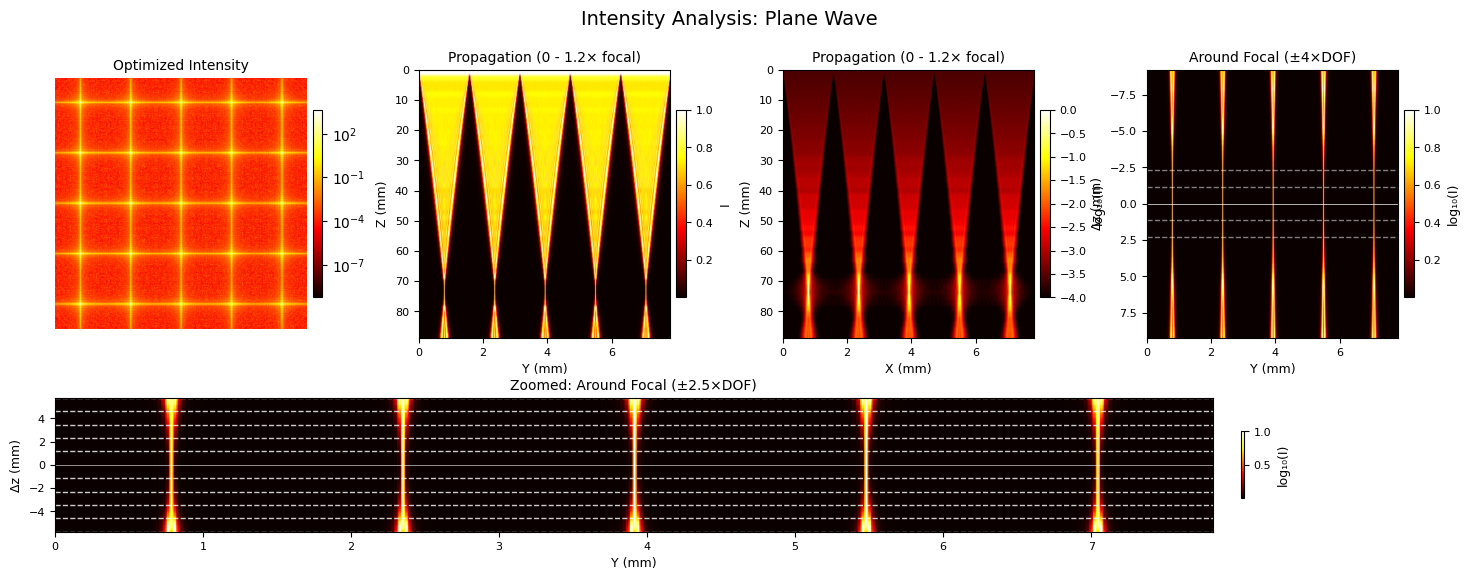

In [2]:
import config
from optics_utils import save_dict_as_json, load_dict_from_json
from phase_generators import PhaseGenerator
# Load default config from config.py
params = {}
params.update(config.COMMON_DEFAULTS)
params.update(config.OPTIMIZED_DEFAULTS)

# overwirte some important params
params['shape'] = slm_manager.shape
params['N'] = 850 # Overwrite ROI size in pix
params['output_size'] = 850 # Overwrite output FOV size in pix
params['roi_center_x'] = 1920 // 2 # Overwrite ROI center in pix
params['roi_center_y'] = 1152 // 2 

# params['roi_center_x'] = 1400 // 2 # Overwrite ROI center in pix
# params['roi_center_y'] = 1120 // 2

params['two_pi_value'] = 210
params['M'] = 5

params['focal_length'] = 73.9e-3


# # temp use
# params['weights'] = {'mse': 0.0,
#                     'depth_in_focus': 0.0,
#                     'depth_out_focus':0.0,
#                     'masked': 0.0,
#                     'eff_mean': 1.0,
#                     'eff_std': 0.0}
# params['N'] = 200
# params['output_size'] = 400
# params['M'] = 2
# params['lr'] = 0.1
# params['ni'] = 100
# params['show_iters'] = 10
# params['mask_count'] = 0


# =========== save/update base.json ==============
# ================================================
save_dict_as_json(params,r".\\config\\base_M5.json")
# save_dict_as_json(params,r".\\config\\base.json")

# Fresnel lens optimizer init
Optimizer2 = PhaseGenerator(params, device=device)
# set to Fresnel mode
Optimizer2.generate(mode='fresnel')
# generate Fresnel phase
phase_8bit = Optimizer2.update_phase_8bit()
# upload to SLM (if in simulation mode, this will not be run)
if not sim_mode:
    slm_manager.upload(phase_8bit)

if Optimizer2.M>1:
    image_size = (Optimizer2.centers_pixel[Optimizer2.M-1][1] - Optimizer2.centers_pixel[0][1])*Optimizer2.pixel_size /(Optimizer2.M-1)
else:
    image_size = Optimizer2.output_size*Optimizer2.pixel_size
spot_dia = Optimizer2.airy_radius
px_count = image_size/spot_dia
print(f"Sub-Image size {image_size*1e3: .2f} mm")
print(f"Sub-Image pixel {px_count: .0f} x{px_count: .0f}")


from visualization import plot_phase,plot_2d_comparisons, plot_cross_sections, plot_energy_distribution
# visualizer (optional)
plot_phase(Optimizer2)
plot_2d_comparisons(Optimizer2)
# plot_cross_sections(Optimizer2,upsampling=3)
# plot_energy_distribution(Optimizer2,upsampling=3)


# # =========== save phase and params ==============
# from optics_utils import save_array, save_dict_as_json
# import os
# filename_json_base = 'fresnel_M9_F73.9.json'
# path_output = r".\\output\\"
# save_array(phase_8bit,os.path.join(path_output,filename_json_base[:-5]))
# save_dict_as_json(params,os.path.join(path_output,filename_json_base))

### Update optimization config and save json

- Load base config from base `.json` file
- (Optional) Update corrent config and set new name by updating `filename_json`
- Save updated config as `.json` if needed (default: `filename_json` is `None`; not save)

### Run optimization, upload (and save copy of `.npy` & `.json`)

Using device: cuda
F/45.04, 74.5 mm
Max. Lens width: 1.654mm
Lens width (Fresnel): 1.654mm
Max. Overlap: 0.0 %

Airy radius: 28.3um
Airy radius (fresnel): 28.3um
Airy correction for Fresnel: 1.000
Depth of focus: 2.09mm
Depth of focus (fresnel): 2.09mm
DOF correction for Fresnel: 1.00

Multi-depth planes are used at F=70.3 (-2.0DOF), 71.4 (-1.5DOF), 72.4 (-1.0DOF), 72.9 (-0.8DOF), 73.5 (-0.5DOF), 74.0 (-0.2DOF), 75.0 (0.2DOF), 75.5 (0.5DOF), 76.1 (0.8DOF), 76.6 (1.0DOF), 77.6 (1.5DOF), 78.7 (2.0DOF) mm
Starting optimization with 500 iterations...
Iter: 1/500
  Focal_mse: 9634.2578 Depth_mse: 9634.2363 Eff_mean: -0.0021 Eff_std: 0.0016 Eff_mean (unweighted):
  0.0001 Eff_std (unweighted): 0.0000 Total: 1.9268e+04
Iter: 51/500
  Focal_mse: 1480.7297 Depth_mse: 7002.1475 Eff_mean: -12.2129 Eff_std: 4.4572 Eff_mean
  (unweighted): 0.6106 Eff_std (unweighted): 0.0891 Total: 8.4751e+03
Iter: 101/500
  Focal_mse: 1181.3904 Depth_mse: 6637.7896 Eff_mean: -13.0324 Eff_std: 0.6081 Eff_mean
  (un

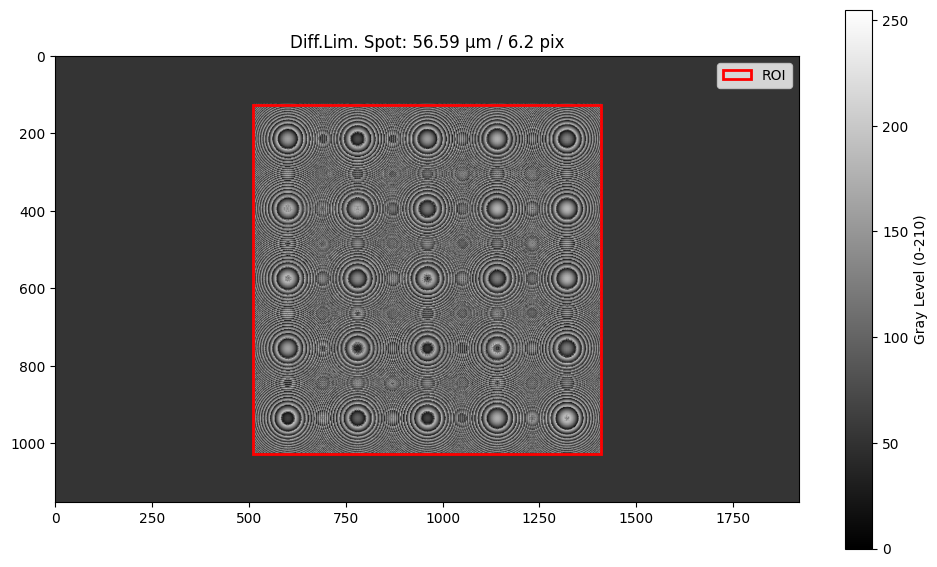

d:\Zihan\code\slm_project\visualization.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


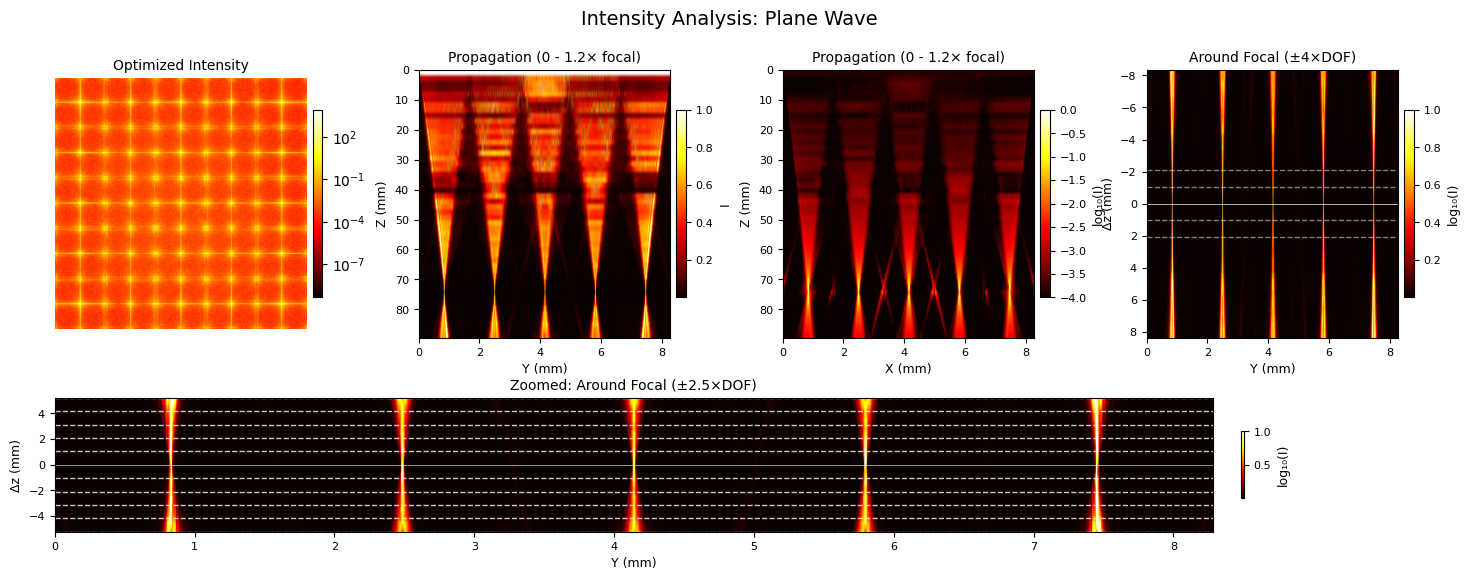

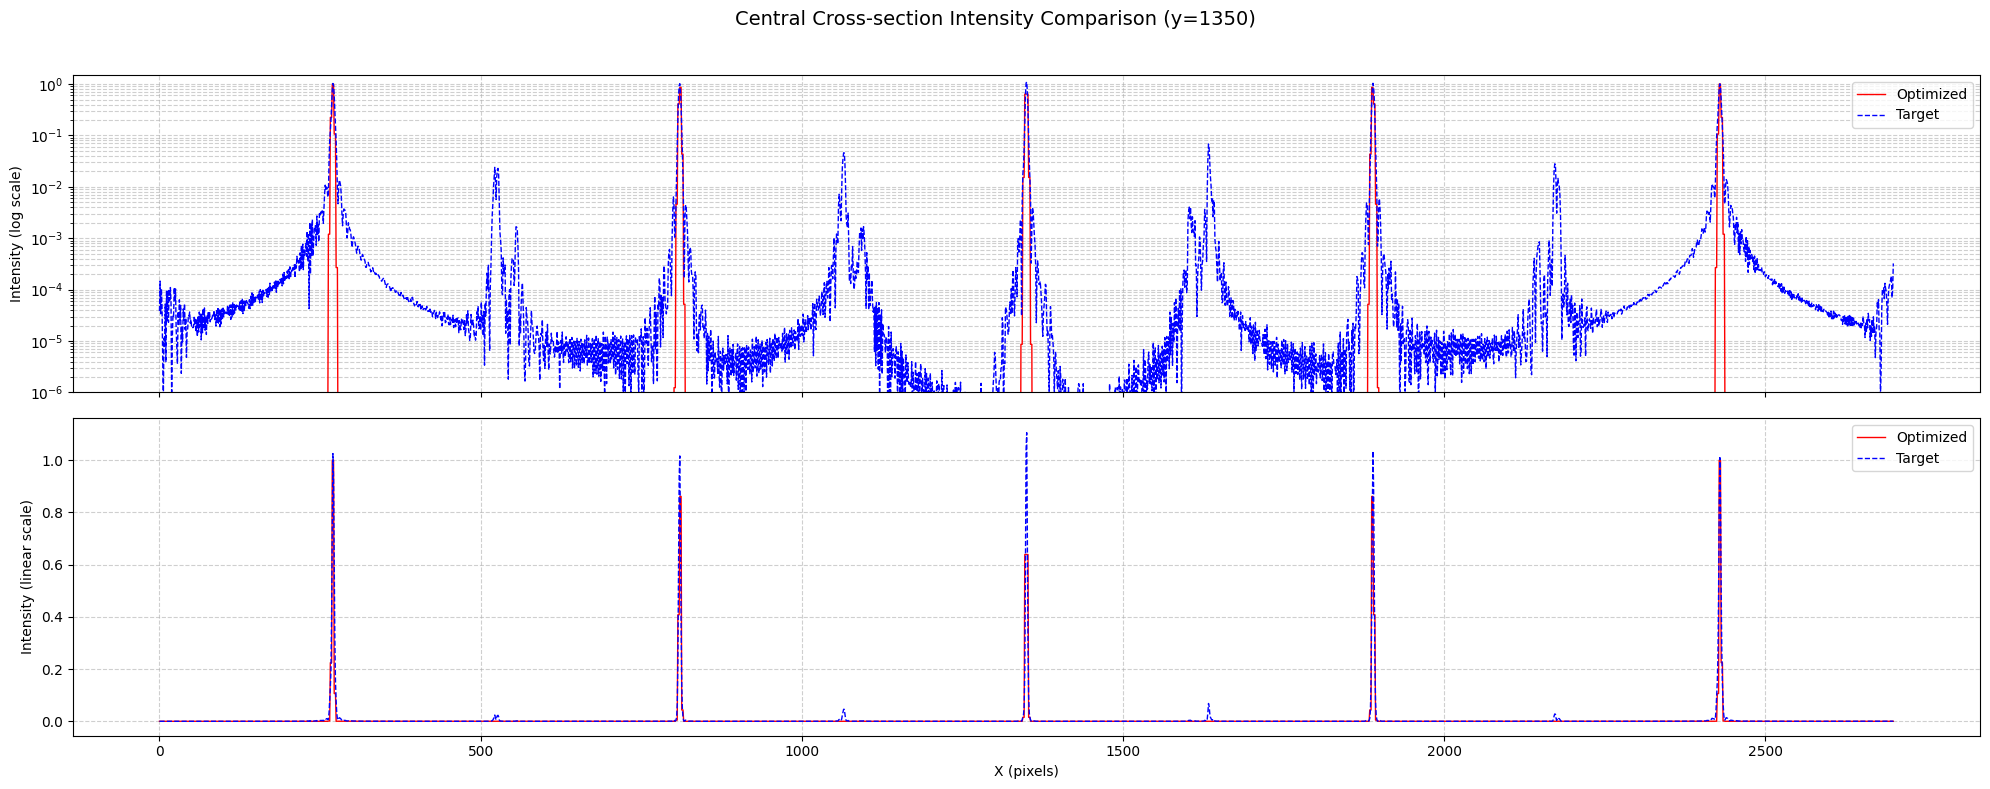


Focusing Efficiency Analysis
Number of focal spots: 25 (M=5x5)

Encircled Energy Calculation:
  Radius: 9.23 pixels = 28.3 μm


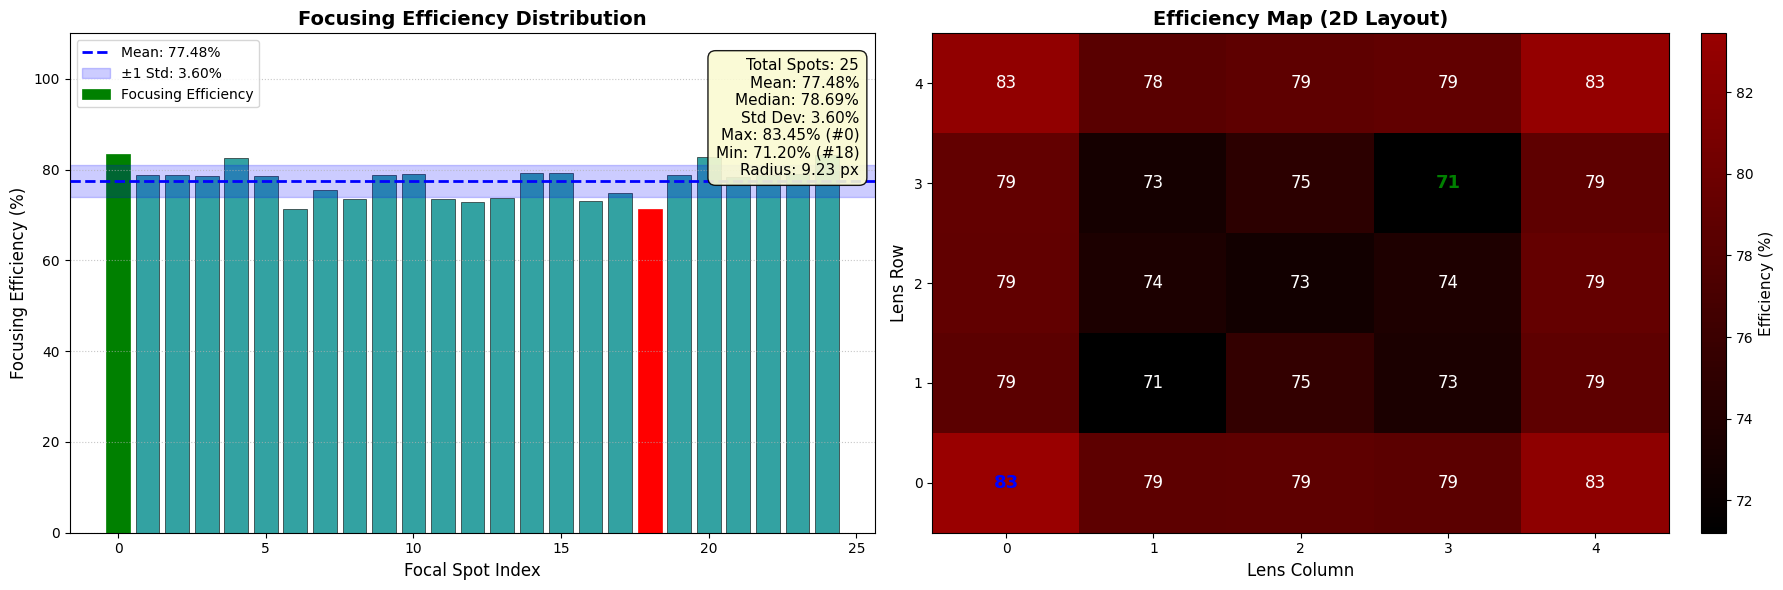

In [ ]:
from optics_utils import save_array
from phase_generators import PhaseGenerator


import os
##### Load base config from exsiting JSON file #####
filename_base = r"base.json"
# filename_base = r"251105_1_super_0.9.json"

##### set to None if not save new json
filename_json = None # if not updated, then not save new json

##### path to load json config files
path_json = r".\\config\\"

############################## load, update (and save new config as json) ###############################
params = load_dict_from_json(os.path.join(path_json,filename_base))


params['mask_count'] = 0
params['overlap_ratio'] = 0.0
# params['depth_in_focus'] = [-2, -1.5, -1, -0.75, -0.5,-0.25,0.25, 0.5, 0.75, 1 , 1.5, 2]
params['airy_correction'] = 0.4
params['M'] = 5
# filename_json = None
# filename_json = 'tmp.json'
filename_json = 'opt20_M5_edof3.json'

# ########## Recipe test_small_1
# params['overlap_ratio'] = 0.8
# params['airy_correction'] = 0.5
# params['mask_count'] = 0
# params['lr'] = 0.1
# params['ni'] = 85
# params['N'] = 300
# filename_json = 'test_small_1' 

########################### for copy and reference
# params['mask_count'] = 9
# params['interleaving'] = 'coarse2'
# params['mask_count'] = 4
# params['interleaving'] = 'coarse2'
# params['mask_count'] = 2
# params['interleaving'] = 'coarse1'
# # EDOF eval z planes
# params['depth_in_focus'] = [-2.5, -1.5, -1, -0.5, 0.5, 1, 1.5, 2.5]

# # ####### save recipe as JSON
# if filename_json is not None:
#     savepath_json = os.path.join(path_json, filename_json)
#     save_dict_as_json(params,savepath_json)
# else:
#     savepath_json = None
#     print('Use exsiting base config...')


######## set output path for npy/json ##################################
# path_output = None
path_output = r".\\output\\"

####### Run optimize and get 8-bit phase output
Optimizer = PhaseGenerator(params, device=device, mode='optimized')
Optimizer._prepare_template()
Optimizer.generate(upsampling=2.0, visualize=False)
phase_8bit = Optimizer.update_phase_8bit()

####### upload to SLM (if in simulation mode, this will not be run)
if not sim_mode:
    slm_manager.upload(phase_8bit)

####### save phase as NPY in same name if path_output is given
if path_output is not None and filename_json is not None:
    save_array(phase_8bit,os.path.join(path_output,filename_json[:-5]))
    save_dict_as_json(params,os.path.join(path_output,filename_json))

from visualization import plot_phase,plot_2d_comparisons, plot_cross_sections, plot_energy_distribution
plot_phase(Optimizer)
plot_2d_comparisons(Optimizer)
plot_cross_sections(Optimizer,upsampling=3)
plot_energy_distribution(Optimizer,upsampling=3)  


### re-load *.npy

In [ ]:
from optics_utils import load_array
import os

path_output = r".\\output\\"

# filename = r"opt1_M9_over0.9_airy1_mask0.npy"
filename = r"opt7_M5_over0.5_airy1_mask0.npy"

#### load npy and upload to SLM again
# phase_8bit = load_array(os.path.join(path_output,filename_json[:-5]+'.npy'))
phase_8bit = load_array(os.path.join(path_output,filename))

if not sim_mode:
    slm_manager.upload(phase_8bit)


Array loaded from: .\\output\\opt7_M5_over0.5_airy1_mask0.npy
Shape: (1152, 1920), dtype: uint8
🚀 Data sent to local hardware


## Show ATF

In [ ]:
import numpy as np
from optics_utils import compute_psf_centers

N = Optimizer.N * 5
pupil_N = Optimizer.N
pupil_pixel_size = Optimizer.pixel_size
pixel_size = Optimizer.pixel_size / 5
atf = Optimizer.compute_transfer_function(N=N, 
                                         pixel_size=pixel_size, 
                                         verbose=False)

# N = Optimizer.N
# atf = Optimizer.compute_local_transfer_function(N=N, 
#                                          pixel_size=pixel_size, 
#                                          verbose=False)

results = compute_psf_centers(Optimizer.M,
            Optimizer.overlap_ratio,
            Optimizer.center_blend,
            z_ratio=1.0,
            N=Optimizer.N,
            device=Optimizer.device)
center_shift = pupil_N // 2 - Optimizer.N // 2
lens_centers = (results['centers_pixel'].cpu().numpy() + center_shift) * Optimizer.pixel_size * 1e3  # mm
lens_width = Optimizer.L / Optimizer.M * 1e3  # mm

import scipy.io as sio
sio.savemat('atf.mat',{'atf':atf,
                         'pixel_size':pixel_size,
                         'wavelength':Optimizer.wavelength,
                         'focal_length':Optimizer.focal_length,
                         'M':Optimizer.M,
                         'spot_radius':Optimizer.airy_radius})

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider
from IPython.display import display

# 计算显示范围
extent_value = 1/(pixel_size*1e3) # mm^-1

def plot_atf(row=0, col=0):
    """绘制指定行列的lenslet ATF"""
    extent_range = [0, extent_value, 0, extent_value]
    lenslet_index = row * Optimizer.M + col
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 绘制相位图
    intensity = np.abs(atf[lenslet_index]).transpose()
    im1 = ax1.imshow(np.angle(atf[lenslet_index].transpose()), 
                     cmap='hsv', 
                     alpha=intensity/np.max(intensity),
                     extent=extent_range, 
                     origin='lower')
    ax1.set_xlabel('X (mm^{-1})', fontsize=12)
    ax1.set_ylabel('Y (mm^{-1})', fontsize=12)
    ax1.set_title(f'Phase - Lenslet [{row}, {col}] (Index: {lenslet_index})', 
                  fontsize=13, fontweight='bold')
    plt.colorbar(im1, ax=ax1, label='rad')
    
    # 绘制幅度图
    im2 = ax2.imshow(np.abs(atf[lenslet_index].transpose()),
                     extent=extent_range, 
                     origin='lower',
                     cmap='viridis')
    ax2.set_xlabel('X (mm^{-1})', fontsize=12)
    ax2.set_ylabel('Y (mm^{-1})', fontsize=12)
    ax2.set_title(f'Amplitude - Lenslet [{row}, {col}] (Index: {lenslet_index})', 
                  fontsize=13, fontweight='bold')
    plt.colorbar(im2, ax=ax2, label='Amp')
    
    plt.tight_layout()
    plt.show()



# 创建交互式滑动条
interact(plot_atf,
         row=IntSlider(min=0, max=Optimizer.M-1, step=1, value=0, description='Row:'),
         col=IntSlider(min=0, max=Optimizer.M-1, step=1, value=0, description='Column:'))